In [2]:
%load_ext dotenv
%dotenv /home/aurora/.env
%matplotlib inline

In [3]:
import numpy as np
import pandas as pd
import datetime as dt
from google.cloud import bigquery
import re
import pymongo
import os
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from flatten_json import flatten
#warnings.filterwarnings('ignore')

In [4]:
# Time
start = dt.datetime(2019,4,5)
end = dt.datetime(2019,5,15)
print(start,end,end-start)

2019-04-05 00:00:00 2019-05-15 00:00:00 40 days, 0:00:00


In [5]:
cursor = pymongo.MongoClient("mongodb://" + os.environ['user'] + ':' + 
                             os.environ['pass'] + '@' + os.environ['db1']  + "/?authSource=" + 
                             os.environ['dbname'])
c_users = cursor.superstars.users
aw = []
for documents in c_users.find({'created_at': {'$lt': end, '$gte': start}},{"sign_up_details":1, "created_at":1,"login_details":1}):
    aw.append(documents)
dic_flattened = [flatten(d) for d in aw]
df = pd.DataFrame(dic_flattened)
df = df[df["sign_up_details_app_platform"] == "UNITY_Android"]
#df = df[df["sign_up_details_device_id"].isin(devices)]
users = df[["_id","created_at","sign_up_details_device_model","login_details_last_request_at"]]
users.columns = ["user_id","createtime","model","last_request"]
print(len(users))
users.head()

125576


,user_id,createtime,model,last_request
0,5ca6adb3b65b15544e169963,2019-04-05 01:21:55.931,Sony F3116,2019-04-05 01:22:16.059
1,5ca6c1bc8c899454486ac253,2019-04-05 02:47:24.829,OPPO RMX1805,2019-04-05 03:09:53.215
2,5ca6d01fd468e03534a80f6d,2019-04-05 03:48:47.021,Xiaomi Redmi 4A,2019-04-05 03:51:56.000
4,5ca6e3fc800ebb353a469cd1,2019-04-05 05:13:32.630,samsung SM-A605F,2019-04-05 10:11:34.754
5,5ca6e9a3acb9c30617a1e75f,2019-04-05 05:37:39.265,OPPO A37f,2019-04-05 05:37:44.384


In [54]:
team_cursor = cursor.superstars.teams
aw = []
for documents in team_cursor.find({'created_at': {'$gte': start}}):
    aw.append(documents)
dic_flattened = [flatten(d) for d in aw]
df = pd.DataFrame(dic_flattened)
df.head()
teams = df[df["user"].isin(users["user_id"])]
teams = teams[["_id","user","entry_league"]]
teams.columns = ["team_id", "user_id", "entry league"]
teams.head()

,team_id,user_id,entry league
0,5ca6adb4b65b15544e169988,5ca6adb3b65b15544e169963,NaN
1,5ca6c1bc8c899454486ac278,5ca6c1bc8c899454486ac253,NaN
2,5ca6d01fd468e03534a80f92,5ca6d01fd468e03534a80f6d,NaN
4,5ca6e3fc800ebb353a469cf6,5ca6e3fc800ebb353a469cd1,NaN
5,5ca6e9a3acb9c30617a1e784,5ca6e9a3acb9c30617a1e75f,NaN


In [55]:
dm = pd.merge(users,teams,on='user_id',how='inner')
dm.head()

,user_id,createtime,model,last_request,team_id,entry league
0,5ca6adb3b65b15544e169963,2019-04-05 01:21:55.931,Sony F3116,2019-04-05 01:22:16.059,5ca6adb4b65b15544e169988,NaN
1,5ca6c1bc8c899454486ac253,2019-04-05 02:47:24.829,OPPO RMX1805,2019-04-05 03:09:53.215,5ca6c1bc8c899454486ac278,NaN
2,5ca6d01fd468e03534a80f6d,2019-04-05 03:48:47.021,Xiaomi Redmi 4A,2019-04-05 03:51:56.000,5ca6d01fd468e03534a80f92,NaN
3,5ca6e3fc800ebb353a469cd1,2019-04-05 05:13:32.630,samsung SM-A605F,2019-04-05 10:11:34.754,5ca6e3fc800ebb353a469cf6,NaN
4,5ca6e9a3acb9c30617a1e75f,2019-04-05 05:37:39.265,OPPO A37f,2019-04-05 05:37:44.384,5ca6e9a3acb9c30617a1e784,NaN


In [139]:
dm['d1'] = (dm['last_request']-dm['createtime'])>'24:00:00'
dm['d3'] = (dm['last_request']-dm['createtime'])>'72:00:00'
dm['d7'] = (dm['last_request']-dm['createtime'])>'168:00:00'
print(len(dm))

125569


In [186]:
dm.sort_values('entry league',ascending = False,inplace = True)
dm.drop_duplicates('user_id')
f = {'user_id':'count','entry league':'count','d1':'sum','d3':'sum','d7':'sum'}
a = dm.groupby('model').agg(f)
a.sort_values('user_id',ascending=False,inplace=True)
a['entry league'] = a['entry league']/a['user_id']
a['d1'] = a['d1']/a['user_id']
a['d3'] = a['d3']/a['user_id']
a['d7'] = a['d7']/a['user_id']

a[['entry league','d1','d3','d7']] = (a[['entry league','d1','d3','d7']]*100).round()
a.rename(columns={'user_id':'no of users','entry league':'league joined %','d1':'d1 %','d3':'d3 %','d7':'d7 %'}, inplace=True)
#A['win rate'] = (A['win rate']*100).round()
print(len(a))
a.head()

1459


,no of users,league joined %,d1 %,d3 %,d7 %
model,,,,,
Xiaomi Redmi Note 4,5354,9.0,22.0,13.0,7.0
Xiaomi Redmi 5A,3976,3.0,14.0,7.0,4.0
samsung SM-J701F,3706,5.0,18.0,10.0,5.0
Xiaomi Redmi Note 5 Pro,3636,13.0,23.0,14.0,8.0
Xiaomi Redmi 6A,3365,5.0,16.0,8.0,4.0


In [189]:
#fig, axs = plt.subplots(nrows = 1, ncols =1, figsize = (20,5))
b = a[0:10]
b = b.reset_index()
#b.drop('no of users',axis=1, inplace=True)
#b['d1 %'].plot(color = 'b',legend = 'percetage of d1 users', ax=axs,style='-0')
#b['d3 %'].plot(color = 'r',legend = 'percetage of d3 users', ax=axs,style='-0')
#b['d7 %'].plot(color = 'm',legend = 'percetage of d7 users', ax=axs,style = '-0')
#b['league joined %'].plot(color = 'y',legend = 'percetage league joined', ax=axs,style = '-0')
#axs.set_ylabel('percentage')
#axs.set_xticklabels(b['model'])
#plt.show()

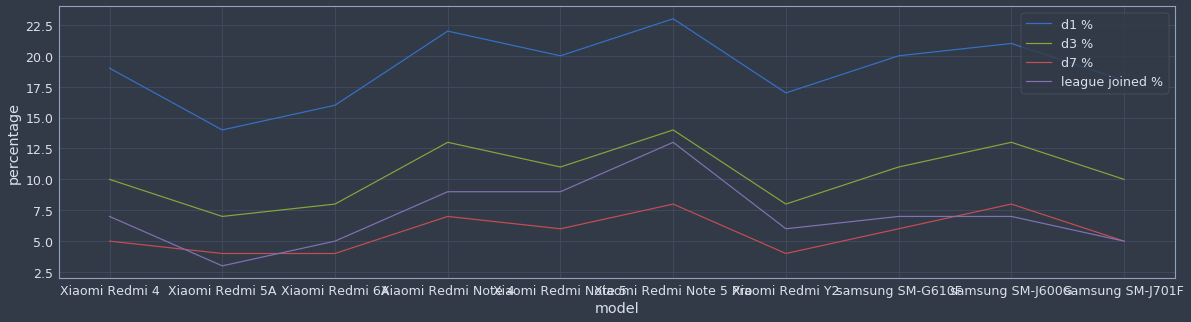

In [201]:

fig, axs = plt.subplots(figsize = (20, 5))
sns.lineplot(x="model", y='d1 %',  data=b, ax = axs,label='d1 %')
sns.lineplot(x="model", y='d3 %',  data=b, ax = axs,label = 'd3 %')
sns.lineplot(x="model", y='d7 %',  data=b, ax = axs,label = 'd7 %')
sns.lineplot(x="model", y='league joined %',  data=b, ax = axs, label = 'league joined %')
axs.set_ylabel('percentage')
#axs.set_ylabel('percentage')
plt.show()